Lasso (Least Absolute Shrinkage and Selection Operator) is a regularization method that adds a penalty to the sum of the absolute values of the coefficients.

Formula for Lasso (L1 Regularization):
Cost/Loss function = MSE + α ∑∣wi∣ 
α is the regularization parameter (controls the strength of regularization),
∣wi∣ is the absolute value of the coefficients.

Lasso sets unneccesory coefficient to zero, so it did feature selection.

Lasso might require a very small alpha.

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_california_housing

In [40]:
data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [41]:
x = df
y = data.target

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [43]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)
sc_y = StandardScaler()
y_train = sc_y.fit_transform(np.array(y_train).reshape(-1,1))

In [44]:
regressor = Lasso()

In [45]:
# parameters = {'alpha':[0.1,0.001,0.02,0.002,0.0005,1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,47,55,70,80,93,99]}
alphas = np.logspace(-4, 1, 100)    
lassocv = GridSearchCV(regressor,{'alpha':alphas},scoring='neg_mean_squared_error',cv=5)
lassocv.fit(x_train,y_train)

,estimator,Lasso()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0....0129700083158)


In [46]:
lassocv.best_params_

{'alpha': np.float64(0.002310129700083158)}

In [47]:
lassocv.best_score_                # its neg mean squared error,consider it +ve

np.float64(-0.39280794065038566)

In [48]:
y_pred_sc = lassocv.predict(x_test)
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1,1))

In [49]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [50]:
score = r2_score(y_test,y_pred) 
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.5972548494578682
MAE: 0.5275083497911022
MSE: 0.5286191633140802


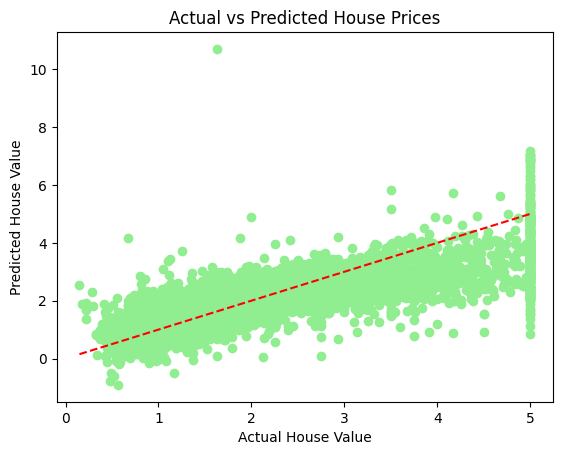

In [51]:
plt.scatter(y_test,y_pred,color="lightgreen")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color="red",linestyle="--")
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Prices')
plt.show()

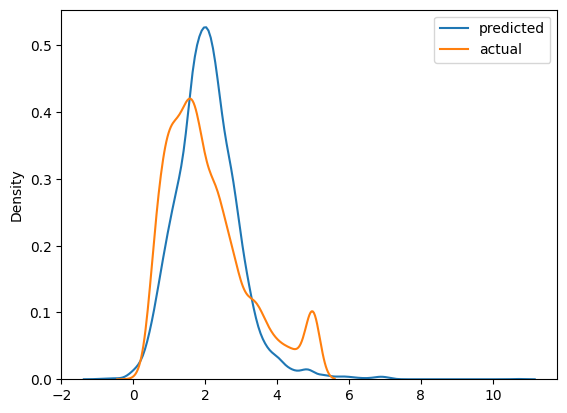

In [52]:
import seaborn as sns
sns.kdeplot(y_pred,label="predicted")
sns.kdeplot(y_test,label="actual")
plt.legend()

In [53]:
y_trains = sc_y.inverse_transform(y_train)
y_trains.max()

np.float64(5.00001)

In [55]:
lasso_coef = lassocv.best_estimator_.coef_
print("Number of zero coefficients in lasso:", np.sum(lasso_coef == 0))  

Number of zero coefficients in lasso: 1
